# Tutorial 5: Native Cheminformatics inside PostgreSQL

This notebook demonstrates `pg_bio` native Morgan fingerprint generation and Tanimoto Similarity capabilities.

In [1]:
import psycopg
import pandas as pd
import matplotlib.pyplot as plt

conn = psycopg.connect("host=localhost port=28818 dbname=pg_bio user=jonatas")

Let's compare **Benzene** to various structural modifications of it.

In [2]:
compounds = [
    ('Benzene', 'C1=CC=CC=C1'),
    ('Toluene', 'CC1=CC=CC=C1'),
    ('Phenol', 'OC1=CC=CC=C1'),
    ('Aspirin', 'CC(=O)OC1=CC=CC=C1C(=O)O'),
    ('Methane', 'C')
]

results = []
with conn.cursor() as cur:
    for name, smiles in compounds:
        cur.execute("SELECT (smiles_to_fingerprint(%s) %% smiles_to_fingerprint('C1=CC=CC=C1'))", (smiles,))
        sim = cur.fetchone()[0]
        results.append({"Compound": name, "SMILES": smiles, "Tanimoto_to_Benzene": float(sim)})

df = pd.DataFrame(results)
df = df.sort_values(by='Tanimoto_to_Benzene', ascending=False)
df

,Compound,SMILES,Tanimoto_to_Benzene
0,Benzene,C1=CC=CC=C1,1.000000
1,Toluene,CC1=CC=CC=C1,0.114286
2,Phenol,OC1=CC=CC=C1,0.114286
3,Aspirin,CC(=O)OC1=CC=CC=C1C(=O)O,0.018182
4,Methane,C,0.000000


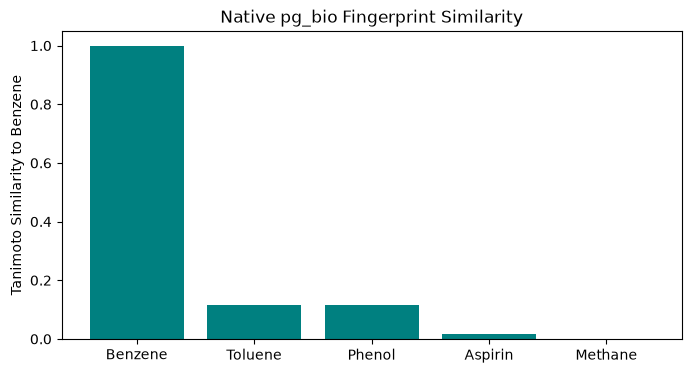

In [3]:
plt.figure(figsize=(8, 4))
plt.bar(df['Compound'], df['Tanimoto_to_Benzene'], color='teal')
plt.ylabel('Tanimoto Similarity to Benzene')
plt.title('Native pg_bio Fingerprint Similarity')
plt.show()